# Persistence

> Removal persistence features from calibrated Euclid images

In [ ]:
# | default_exp euclid.persistence

The most obvious persistence features are near-vertical streaks, due to bright sources in the grism-dispersed images that are interleaved with the dithered JHY exposures. The appearance of those bright sources in the un-dispersed exposures also produces roughly circular persistence features.

This approach attempts to identify and remove persistence features using only the calibrated J-, H-, and Y-band exposures available in the science archive, i.e. with no access to calibrations. It uses the idea that persistence signals (from the current and previous observation ROSs) should be present in each exposure, but with some decay over time. The sky sources move between dithers, so taking the minimum value over a stack of sequential dithers (which can extend across multiple observation ROSs), produces an estimate of the persistence. Since the persistence features are decaying, the minimum will typically correspond to the time of the last image in the sequence, but to be more precise we use the time corresponding to the minimum flux for each pixel. We only stack images for a single filter at a time, as they have different background levels and each JHY sequence is taken with (almost) the same pointing (so they do not help with rejecting sky sources).

If no persistence features were created during the exposure sequence, then the above approach would suffice. However, if a feature is created in the middle of a stack, then the minimum flux will occur _before_ the persistence appeared, and hence not provide any information about the persistence. Conversely, if a persistence feature does not appear until after the target image (which we want to correct), then we do not want to include the persistence feature. We therefore need to mask pixels in the stack depending on when the persistence feature is created. To do so, we can use the fact that recently-formed persistence features are flagged in the DQ image. Those created by a dispersed exposure are flagged in the DQ extensions for the subsequent JHK sequence. We record the latest time a persistence feature is flagged for each pixel in the image. If that time is equal to or prior to the target image, then we mask pixels earlier in the stack. If it is after the target image, then we mask pixels later in the stack. Finally, we need to completely mask any pixels where there are fewer than three unmasked pixels remaining in the stack, since the minimum may be contaminated by sky sources.

At this point we have, for each pixel, an estimate for the persistence flux, the time since the last persistence feature was created (if it occurred within the sequence), and the time between the target exposure (which we want to correct) and our persistence estimate.

The persistence estimate is lower than the true persistence in the target image, since the persistence has decayed in the intervening time. Simply subtracting the persistence estimate from the target image would be an improvement, but would not remove all of the persistence. However, if we can model the decay, then we can rescale the persistence estimate to the time of the target image.

To determine a suitable model, we combine all the persistence estimates and run source detection to find the bright features. We then plot the log(flux) of each feature against the time since the persistence feature was created. These results show that the flux decay is well modelled by a power-law. The slope (power-law index) varies from feature to feature. This may reflect different decay rates depending on position on the detector, brightness of the originating source, etc. This warrants further attention and could improve the correction. However, as a simple first approach, we take a rough median slope, $f(t)/f(0) = 10^{9t}$, where $t$ is the elapsed time in days. For pixels where a persistence feature has not appeared within the stack, the slope is taken to be zero, i.e. the estimate is used unchanged.

After applying this scaling, we have an improved persistence estimate for each target image. The duration for each JHY sequence is small compared to the decay time, so it is beneficial to median combine the three estimates to slightly reduce the noise, resulting in a correction for each dither. Finally, this correction is subtracted from each original image.

All the above steps operate on a single extension at a time, reducing memory usage, or potentially allowing multiple extensions to be processed in parallel.

In [ ]:
# | export
import numpy as np
import os
import shutil
from astropy.io import fits
from glob import glob

from nicl.euclid.utilities import (get_nisp_images_for_observation, get_primary_header, get_persistence_mask,
                                   get_invalid_mask, get_rms, fits_append)

In [ ]:
from astropy.convolution import convolve
from astropy.io import fits
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip
from glob import glob
from matplotlib import pyplot as plt
from photutils.segmentation import deblend_sources, detect_sources, detect_threshold, make_2dgaussian_kernel, SourceCatalog
from scipy.ndimage import median_filter

In [ ]:
# | iexport

def forward_fill(arr, axis=-1):
    arr = np.atleast_1d(arr)
    mask = np.isnan(arr)
    idx = np.indices(arr.shape)
    idx[axis][mask] = 0
    np.maximum.accumulate(idx[axis], axis=axis, out=idx[axis])
    out = arr[*idx]
    return out

In [ ]:
# | iexport

def minimum_map(fns, mask, extname, n_leading=0, correct=True):
    images = np.array([fits.getdata(fn, extname=extname) for fn in fns])
    rms = np.median(get_rms(fns.iloc[n_leading], extname))
    # add invalid pixels to the mask
    masked = np.array([get_invalid_mask(fn, extname) for fn in fns])
    # add the input mask to the mask, this is used to mask pixels prior to the
    # appearance of a persistence feature that affects some of the images
    masked |= mask
    # if there are less than three unmasked pixels after the target image
    # then the minimum will not work for rejecting on-sky sources, mask the
    # pixels completely to reflect our lack of knowledge
    n_ok = (~masked).sum(axis=0)
    masked |= n_ok < 3
    # set masked pixels to infinity, so they are ignored when taking the minimum
    images[masked] = np.inf
    images_idx_sorted = np.argsort(images, axis=0)
    images_sorted = np.take_along_axis(images, images_idx_sorted, axis=0)
    images_sorted[np.isinf(images_sorted)] = np.nan
    minimum_idx = images_idx_sorted[0]
    minimum = images_sorted[0]
    # estimate error on the minimum from difference versus next smallest value
    minimum_err = images_sorted[1] - minimum
    if correct:
        # correct the bias in using the minimum of different numbers of
        # samples to estimate the median
        for n in range(3, n_ok.max() + 1):
            r = np.random.normal(size=(n, 100000))
            bias = np.mean(np.min(r, axis=0))
            with_n = n_ok == n
            minimum[with_n] -= bias * rms
    # now set invalid pixels to zero
    invalid = np.isnan(minimum)
    minimum[invalid] = 0
    # subtract the median background
    min_med = np.median(minimum)
    minimum -= min_med
    minimum[invalid] = 0  
    return minimum, minimum_err, minimum_idx

In [ ]:
# | iexport

def mjd_of_last_persistence(fns):
    mjd = np.dstack([fits.getval(fn, 'mjd-obs') for fn in fns])
    p = np.dstack([get_persistence_mask(fn, extname=ext) for fn in fns])
    # the persistence features from the dispersed image are shared by all the
    # images in a JHY block, so remove entries from H and Y masks
    p = p.reshape(p.shape[:2] + (-1, 3))
    for i in [2, 1]:
        p[..., i] = np.where(p[..., i] & p[..., i-1], False, p[..., i]) 
    p = p.reshape(p.shape[:2] + (-1,))
    last = forward_fill(np.where(p, mjd, np.nan))
    #last = np.nan_to_num(last)
    last = np.moveaxis(last, -1, 0)
    return last

In [ ]:
# | iexport

def calc_rolling_minimum(
    image_info,  # a DataFrame of image information
    ext,  # the image extension on which to operate
    n_roll=4,  # the number of images in the rolling window after and including the target
    n_leading=4,  # the number of images to include in window before the target
    correct_min=True,  # apply a correction for estimating the mean using the minimum of a sample
    debug=False,  # print some useful debugging information
):
    """Determine the rolling minimum for each image in a sequence.

    For each image in the supplied `image_info`, the sequence of `n_roll` images in each filter is
    considered. The minimum value for each pixel is determined over the sequence. This is saved as
    `min_{obs_id}_{i}_{j}_{filter}.fits`
    """
    primary_header = get_primary_header(image_info.filename)
    filter_sequence = "JHY"
    n_filters = len(filter_sequence)
    last_persistence = mjd_of_last_persistence(image_info.filename)
    eps = 1 / 60 / 60 / 24
    for i in range(n_leading * n_filters, len(image_info) - (n_roll - 1) * n_filters):
        target = image_info.iloc[i]
        mjd = target["mjd"]
        filt = target["filter"]
        filter_index = filter_sequence.index(filt)
        filter_image_info = image_info[i - n_leading * n_filters: i + n_roll * n_filters: n_filters]
        lp = last_persistence[i + (n_roll - 1) * n_filters]
        if debug:
            print(i, filt, i + n_roll * n_filters, target.filename[-50:])
            print(filter_image_info.filename.str[-50:])
            print(filter_image_info["mjd"])
            print(np.nanmax(lp))
        dt_lp = np.reshape(filter_image_info["mjd"], (-1, 1, 1)) - lp
        dt_lp_target = target["mjd"] - lp
        # if a persistence feature appears in or prior to the target, mask pixels before the appearence of the feature 
        mask = (dt_lp_target > -eps) & (dt_lp < -eps)
        # if a persistence feature appears after the target, mask pixels after the appearence of the feature 
        mask |= (dt_lp_target < -eps) & (dt_lp > -eps)
        mask[np.isnan(mask)] = False
        minimum, minimum_err, minimum_idx = minimum_map(filter_image_info.filename, mask=mask,
                                                        extname=ext, n_leading=n_leading, correct=correct_min)
        dt_lp = np.take_along_axis(dt_lp, np.expand_dims(minimum_idx, 0), axis=0).squeeze()
        dt_lp = np.minimum(dt_lp, 1)
        dt = dt_lp - dt_lp_target
        min_fn = os.path.join(outpath, f"min_{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}.fits")
        fits_append(min_fn, minimum, ext, primary_header)
        if debug:
            lp_fn = os.path.join(outpath, f"lp_{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}.fits")
            fits_append(lp_fn, lp, ext, primary_header)
        dt_lp_fn = os.path.join(outpath, f"dt_lp_{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}.fits")
        fits_append(dt_lp_fn, dt_lp, ext, primary_header)
        dt_fn = os.path.join(outpath, f"dt_{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}.fits")
        fits_append(dt_fn, dt, ext, primary_header)
        img = fits.getdata(target["filename"], extname=ext)
        img_fn = os.path.join(outpath, f"img_{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}.fits")
        fits_append(img_fn, img, ext, primary_header)

In [ ]:
path = "/Users/spb/data/euclid/q1/clusters/MCXC_J1743.3+6440"

In [ ]:
images = get_nisp_images_for_observation(2070, n_prior=1, n_after=1, path=path)

In [ ]:
dets = [f"DET{i}{j}" for j in range(1, 5) for i in range(1, 5)]
sci_exts = [f"{d}.SCI" for d in dets]
sci_exts = ["DET44.SCI"]

In [ ]:
outpath = os.path.join(path, "persistence")
try:
    shutil.rmtree(outpath)
except FileNotFoundError:
    pass
os.mkdir(outpath)

In [ ]:
%%time 
for ext in sci_exts:
    calc_rolling_minimum(images, ext, n_leading=4, correct_min=True)

CPU times: user 50.9 s, sys: 11.7 s, total: 1min 2s
Wall time: 1min 15s


In [ ]:
fns = glob(os.path.join(outpath, "min_*.fits"))
fns = sorted(fns)

mean_img = None
for fn in fns:
    img = fits.getdata(fn)
    if mean_img is None:
        mean_img = img
    else:
        mean_img += img
mean_img /= len(fns)

bkg = median_filter(mean_img, 25)
mean_img_bkg_sub = mean_img - bkg

threshold = detect_threshold(mean_img_bkg_sub, nsigma=1.0)
kernel = make_2dgaussian_kernel(2.0, size=7)
det_img = convolve(mean_img_bkg_sub, kernel)
segm = detect_sources(
    data=det_img,
    threshold=threshold,
    npixels=25,
)
segm_deblend = deblend_sources(
    det_img,
    segm,
    npixels=25,
    nlevels=32,
    contrast=0.1,
    progress_bar=True,
)
fits.writeto(os.path.join(outpath, "segm.fits"), segm.data, overwrite=True)
fits.writeto(os.path.join(outpath, "segm_deblend.fits"), segm_deblend.data, overwrite=True)

In [ ]:
segm_fluxes = []
segm_dt_lp = []
for fn in fns:
    img = fits.getdata(fn)
    cat = SourceCatalog(img, segm_deblend)
    segm_fluxes.append(cat.segment_flux)
    img = fits.getdata(fn.replace('min', 'dt_lp'))
    cat = SourceCatalog(img, segm_deblend)
    segm_dt_lp.append(cat.segment_flux / cat.area)
segm_fluxes = np.array(segm_fluxes)
segm_fluxes = np.maximum(segm_fluxes, 1)
segm_log_fluxes = np.log10(segm_fluxes)
segm_dt_lp = np.array(segm_dt_lp)

In [ ]:
brightest = segm_fluxes.max(axis=0).argsort()[-100:]

In [ ]:
def fit_persistence_decay(dt, flux):
    slope = -10
    mask = (dt > 0) & (dt < 0.1)
    dt = dt[mask]
    flux = flux[mask]
    fit = fitting.LinearLSQFitter()
    or_fit = fitting.FittingWithOutlierRemoval(fit, sigma_clip, niter=3, sigma=2.0)
    line_init = models.Linear1D(slope=slope, fixed=dict(slope=False))
    fitted_line, mask = or_fit(line_init, dt, flux)
    return fitted_line, mask

In [ ]:
decay_fits = {}
clipped = {}
for b in brightest:
    x = segm_dt_lp[:, b]
    y = segm_log_fluxes[:, b]
    decay_fits[b], clipped[b] = fit_persistence_decay(x, y)

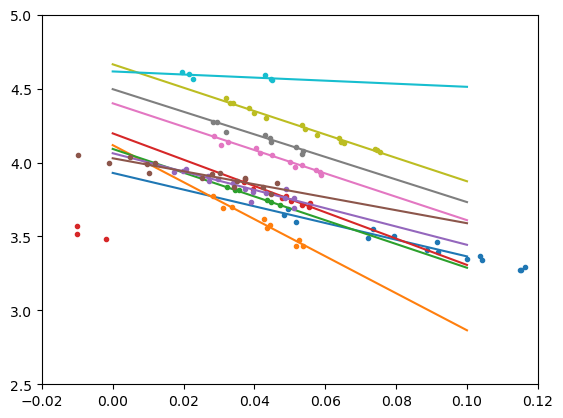

In [ ]:
x = np.array([0.0, 0.1])
for b in brightest[::10]:
    p = decay_fits[b]
    points = plt.plot(segm_dt_lp[:, b], segm_log_fluxes[:, b], '.');
    plt.plot(x, p(x), '-', color=points[0].get_color())
plt.xlim(xmin=-0.02, xmax=0.12)
plt.ylim(2.5, 5);

In [ ]:
slope, intercept = np.transpose([(d.slope.value, d.intercept.value) for d in decay_fits.values()])

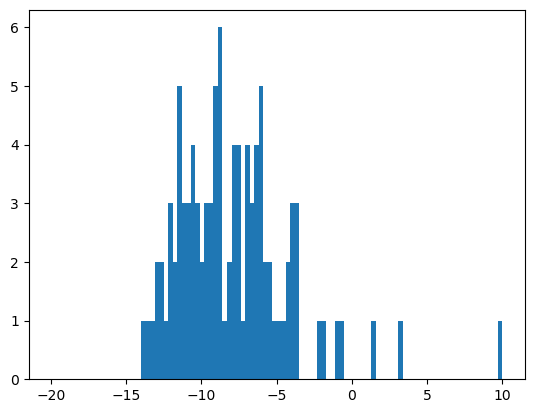

In [ ]:
plt.hist(slope, bins=100, range=(-20, 10));

In [ ]:
np.nanmedian(slope)

-8.487246307734761

In [ ]:
primary_header = get_primary_header(fns)

In [ ]:
fns = glob(os.path.join(outpath, "min_*.fits"))
fns = sorted(fns)

In [ ]:
for fn in fns:
    flux = fits.getdata(fn)
    dt = fits.getdata(fn.replace('min', 'dt'))
    dt = np.nan_to_num(dt)
    dt[dt > 0.15] = 0.0
    dt[dt < 0.01] = 0.0
    #mad = median_abs_deviation(flux, axis=None, scale="normal")
    #dt[flux < 3 * mad] = 0.0
    corr_flux = flux * 10**(9 * dt)
    outfn = fn.replace('min', 'corr')
    fits_append(outfn, corr_flux, ext, primary_header)

In [ ]:
corr_fns = glob(os.path.join(outpath, 'corr_*.fits'))
corr_fns = np.array(sorted(corr_fns))

In [ ]:
for fns in corr_fns.reshape((-1, 3)):
    imgs = np.array([fits.getdata(fn, extname=ext) for fn in fns])
    med = np.median(imgs, axis=0)
    outfn = fns[0].replace('_0_J', '').replace('corr', 'persistence')
    fits_append(outfn, med, ext, primary_header)

In [ ]:
for i in range(len(images)):
    target = images.iloc[i]
    fn = target['filename']
    pers_fn = os.path.join(outpath, f'persistence_{target["obs_id"]}_{target["dithobs"]}.fits')
    if os.path.exists(pers_fn):
        pers = fits.getdata(pers_fn, extname=ext)
        img = fits.getdata(fn, extname=ext)
        img -= pers
        outfn = os.path.join(outpath, os.path.basename(fn))
        fits_append(outfn, img, ext, primary_header)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()